In [ ]:
# CELL 1: Imports and Load Dataset
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Test images shape     :", x_test.shape)
print("Test labels shape     :", y_test.shape)
print("Pixel value range     :", x_train.min(), "–", x_train.max())
print("Classes               :", class_names)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Test images shape     : (10000, 32, 32, 3)
Test labels shape     : (10000, 1)
Pixel value range     : 0 – 255
Classes               : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# CELL 11
# MEMBER 4: Removing Duplicate Data
import hashlib

# Step 1: Create a unique fingerprint (hash) for each image and check for repeats
def hash_image(img):
    return hashlib.md5(img.tobytes()).hexdigest()

train_hashes = [hash_image(img) for img in x_train]
duplicates = len(train_hashes) - len(set(train_hashes))
print("Duplicate images found:", duplicates)

# Step 2: Remove duplicates if found, keeping only the first copy
if duplicates > 0:
    seen = set()
    keep_indices = [i for i, h in enumerate(train_hashes) if h not in seen and not seen.add(h)]
    x_train_dedup = x_train[keep_indices]
    y_train_dedup = y_train[keep_indices]
    print(f"Removed {duplicates} duplicate images")
else:
    x_train_dedup = x_train
    y_train_dedup = y_train
    print("No duplicates found — all images are unique")

Duplicate images found: 0
No duplicates found — all images are unique


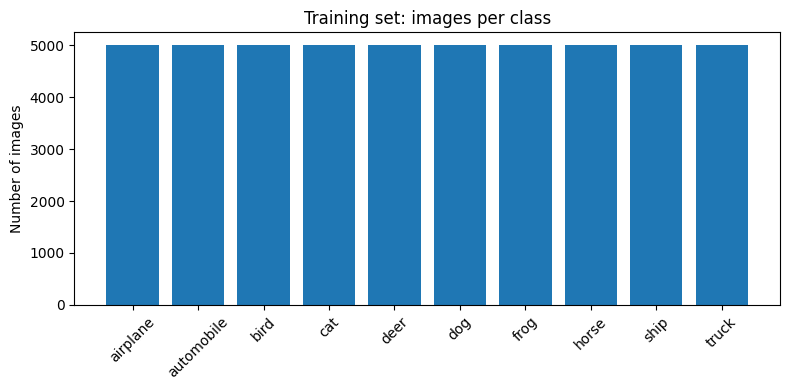

Min count: 5000 | Max count: 5000


In [ ]:
# CELL 12: Class distribution bar chart
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar([class_names[i] for i in unique], counts)
plt.xticks(rotation=45)
plt.ylabel("Number of images")
plt.title("Training set: images per class")
plt.tight_layout()
plt.show()

print("Min count:", counts.min(), "| Max count:", counts.max())